<a href="https://colab.research.google.com/github/mammu2007/myproject.ipynb/blob/main/myproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Content of food.txt (first 200 chars):
 Order_ID,Customer_ID,Order_Time,Location,Item,Category,Quantity,Price,Rating 1001,C001,2025-01-01 12:15:00,Chennai,Pizza,Fast Food,2,250,4.5 1002,C002,2025-01-01 13:20:00,Madurai,Burger,Fast Food,1,18 ...

DataFrame head after loading new data:
   Order_ID Customer_ID           Order_Time    Location        Item  \
0      1001        C001  2025-01-01 12:15:00     Chennai       Pizza   
1      1002        C002  2025-01-01 13:20:00     Madurai      Burger   
2      1003        C003  2025-01-01 18:45:00  Coimbatore     Biryani   
3      1004        C004  2025-01-02 19:30:00     Chennai        Dosa   
4      1005        C005  2025-01-02 20:10:00      Trichy  Fried Rice   

       Category  Quantity  Price  Rating  
0     Fast Food         2    250     4.5  
1     Fast Food         1    180     4.2  
2   Main Course         3    220     4.8  
3  South Indian         2     90     4.1  
4       Chinese         1    160     4.0  
Rows: 20
Columns: 9
<cla

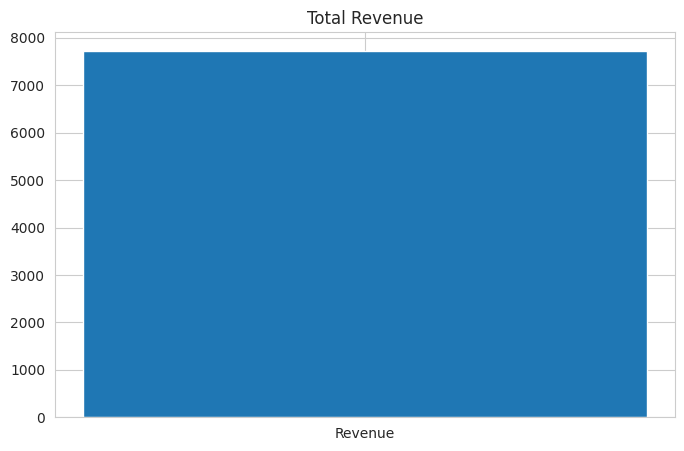

Day
Friday       3
Monday       2
Saturday     2
Sunday       2
Thursday     4
Tuesday      2
Wednesday    5
Name: Order_ID, dtype: int64


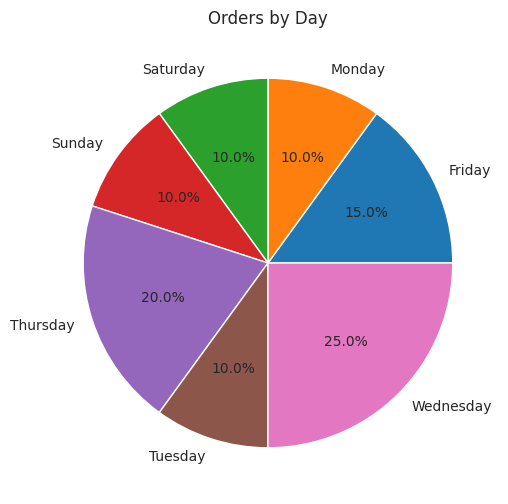

Location
Chennai       2770
Coimbatore    2040
Madurai       1090
Salem         1040
Trichy         790
Name: Sales, dtype: int64


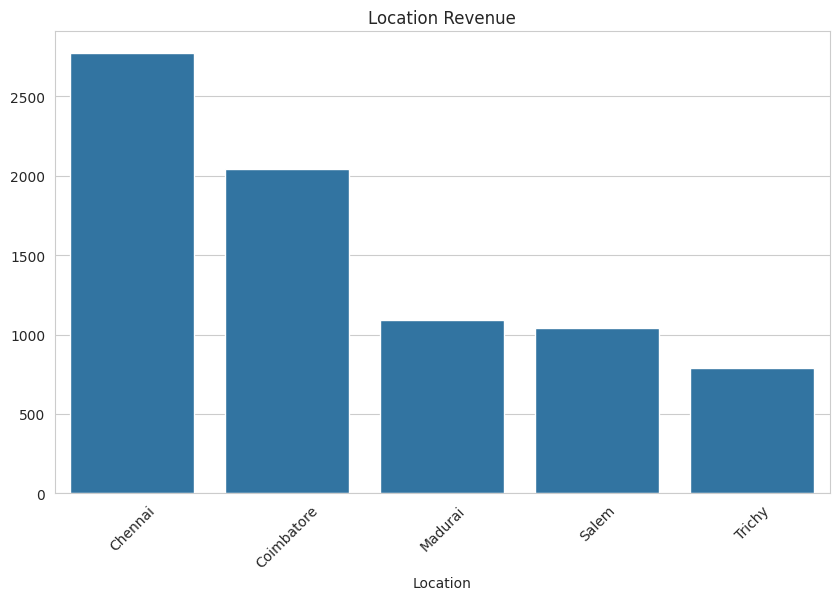

Customer_ID
C001    2
C002    2
C003    2
C004    1
C005    1
Name: Order_ID, dtype: int64
Customer_ID
C001    2
C002    2
C003    2
C004    1
C005    1
C006    1
C007    1
C008    1
C009    1
C010    1
Name: Order_ID, dtype: int64


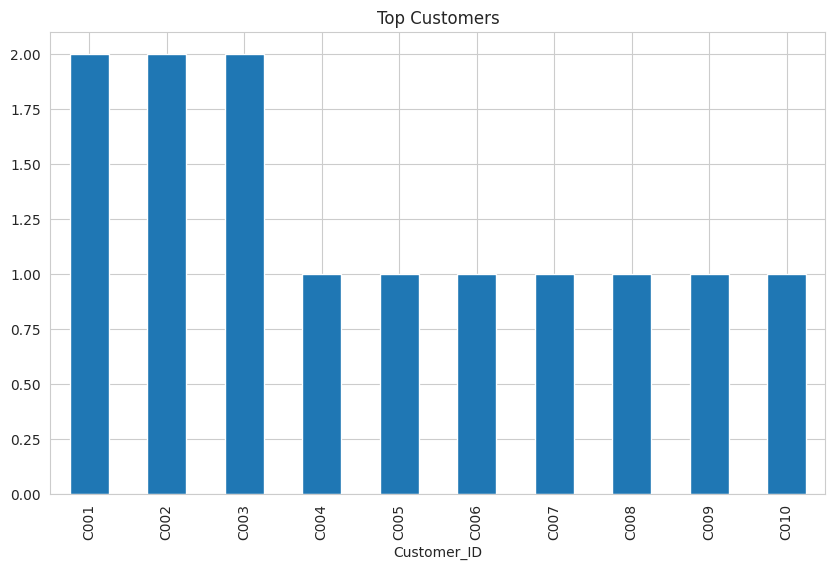

Month
January    7730
Name: Sales, dtype: int64


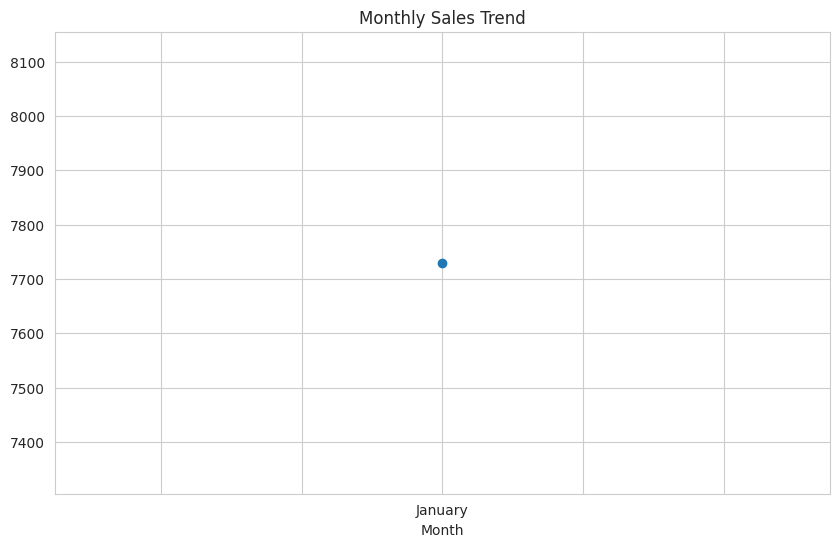

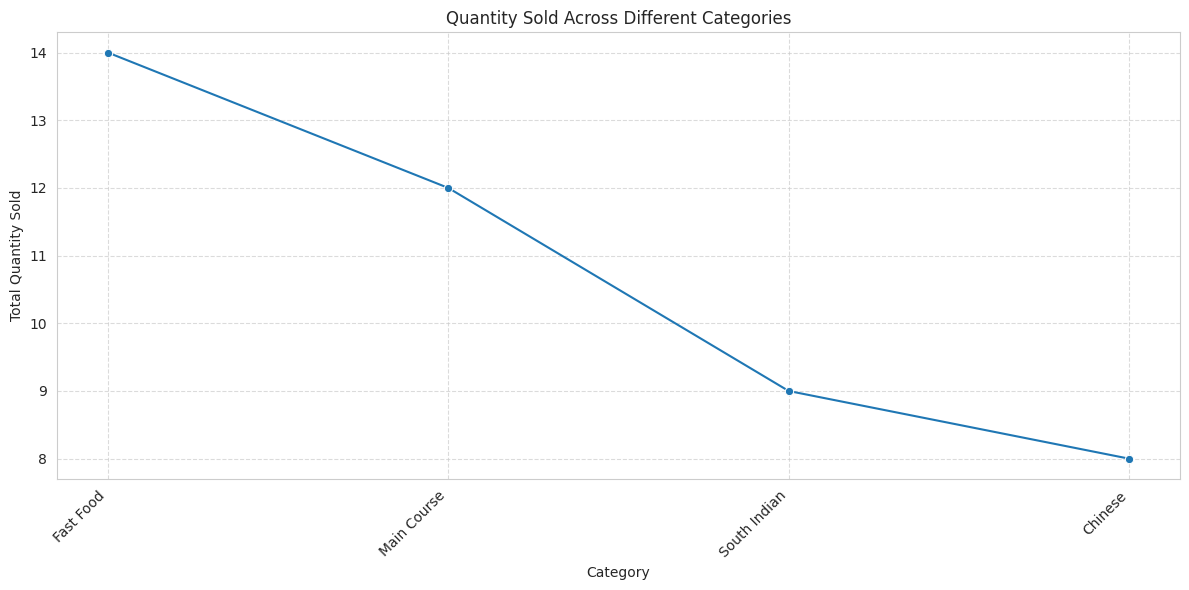

          Quantity     Price     Sales    Rating
Quantity  1.000000 -0.356675  0.682275  0.138504
Price    -0.356675  1.000000  0.389406  0.725958
Sales     0.682275  0.389406  1.000000  0.674941
Rating    0.138504  0.725958  0.674941  1.000000


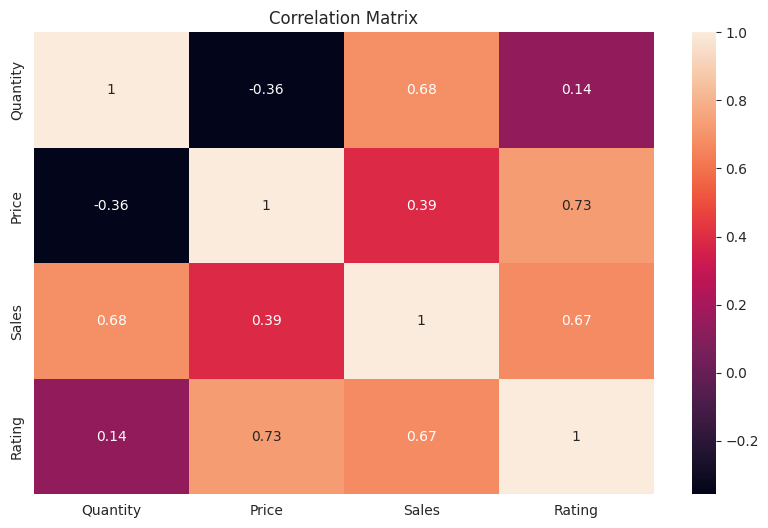

FOOD DELIVERY BUSINESS INSIGHTS

Total Revenue: 7730

Best Performing Location: Chennai


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import re

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")

# Read the content of 'food.txt'
with open("food.txt", "r") as file:
    data = file.read()

print("Content of food.txt (first 200 chars):\n", data[:200], "...\n")

corrected_data = re.sub(r"Rating ", r"Rating\n", data, 1)


corrected_data = re.sub(r" (\d{4},)", r"\n\1", corrected_data)

# Create DataFrame from the new data (food.txt)
df = pd.read_csv(io.StringIO(corrected_data))

print("DataFrame head after loading new data:")
print(df.head())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

df.describe()

print(df.isnull().sum())

df.drop_duplicates(inplace=True)

df.dropna(inplace=True)


# 'Order_Time' in new data corresponds to 'Order_Date' in previous analysis
df['Order_Date'] = pd.to_datetime(df['Order_Time'])

df['Day'] = df['Order_Date'].dt.day_name()

df['Month'] = df['Order_Date'].dt.month_name()

# 'Sales' calculation using 'Quantity' and 'Price' from new data
df['Sales'] = df['Quantity'] * df['Price']

total_sales = df['Sales'].sum()

print("Total Revenue:", total_sales)

plt.figure(figsize=(8,5))

plt.bar(["Revenue"], [total_sales])

plt.title("Total Revenue")

plt.show()

daily_orders = df.groupby('Day')['Order_ID'].count()

print(daily_orders)

daily_orders.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Orders by Day")

plt.ylabel("")

plt.show()

# 'Location' in new data corresponds to 'City' in previous analysis
location_sales = df.groupby(
    'Location' # Using Location column for analysis
)['Sales'].sum()

location_sales = location_sales.sort_values(
    ascending=False
)

print(location_sales)

sns.barplot(
    x=location_sales.index,
    y=location_sales.values
)

plt.xticks(rotation=45)

plt.title("Location Revenue")

plt.show()

# 'Customer_ID' in new data corresponds to 'Customer_Name' in previous analysis
customer_orders = df.groupby(
    'Customer_ID' # Using Customer_ID for customer analysis
)['Order_ID'].count()

print(customer_orders.head())

top_customers = customer_orders.sort_values(
    ascending=False
)

print(top_customers.head(10))
top_customers.head(10).plot(
    kind='bar'
)

plt.title("Top Customers")

plt.show()

monthly_sales = df.groupby(
    'Month'
)['Sales'].sum()

print(monthly_sales)

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Sales Trend")

plt.show()

category_quantity = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.lineplot(x=category_quantity.index, y=category_quantity.values, marker='o')
plt.title('Quantity Sold Across Different Categories')
plt.xlabel('Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# New available numerical columns for correlation: 'Quantity', 'Price', 'Sales', 'Rating'
corr = df[
    ['Quantity',
     'Price',
     'Sales',
     'Rating']
].corr()

print(corr)
sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

# The comments about missing 'Hour', 'Item', 'Category' are now outdated
# as 'Item' and 'Category' exist, and 'Hour' can be derived from 'Order_Time'.
# I'll keep the current analysis focused on the main issue for now.

print("="*50)
print("FOOD DELIVERY BUSINESS INSIGHTS")
print("="*50)

print(
    "\nTotal Revenue:",
    round(total_sales,2)
)

# 'Item' column is now present, popular item analysis can be re-added if desired.
# 'Order_Time' is present, peak ordering hour can be analyzed.

print(
    "\nBest Performing Location:",
    location_sales.idxmax()
)

# 'Rating' column is now present, average customer rating can be analyzed.

print("="*50)